# 💳 Credit Card Fraud Detection — Portfolio Edition
**Stack:** XGBoost · SMOTE · Scikit-learn Pipelines · 6.3M transactions

### Goals
1. Handle extreme class imbalance (0.13% fraud) properly
2. Train a high-precision XGBoost classifier
3. Evaluate with the right metrics (Precision-Recall, not just Accuracy)
4. Export a production-ready pipeline

## 1. Setup & Imports

In [1]:
# Install required packages if not already present
%pip install xgboost imbalanced-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import joblib

print('All imports successful ✅')

All imports successful ✅


## 2. Load & Inspect Data

In [3]:
df = pd.read_csv('AIML Dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['isFraud'].value_counts())
print(f'\nFraud rate: {df["isFraud"].mean()*100:.3f}%')

Dataset shape: (6362620, 11)

Class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.129%


## 3. Feature Engineering
Good features matter more than model choice. We'll engineer signals that capture suspicious transaction patterns.

In [ ]:
def engineer_features(df):
    df = df.copy()

    # Balance difference features 
    df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
    df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

    # New: Did the origin account get completely drained? 
    # Fraudsters often drain accounts completely before disappearing
    df['origDrained'] = (
        (df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)
    ).astype(int)

    # --- New: Does the transaction amount exactly match the sender's balance? ---
    # A hallmark of fraud: transfer out exactly what you have
    df['amountEqualsOldBalance'] = (
        df['amount'] == df['oldbalanceOrg']
    ).astype(int)

    # --- New: Unexplained destination balance change ---
    # If dest balance didn't increase by the transfer amount, something's off
    df['destBalanceMismatch'] = abs(
        df['balanceDiffDest'] - df['amount']
    )

    # --- New: Log-transform amount to reduce skew ---
    df['logAmount'] = np.log1p(df['amount'])

    # --- New: Zero-balance destination (mule account pattern) ---
    df['destWasEmpty'] = (df['oldbalanceDest'] == 0).astype(int)

    return df

df = engineer_features(df)
print('Feature engineering complete ✅')
print(f'Features added: origDrained, amountEqualsOldBalance, destBalanceMismatch, logAmount, destWasEmpty')

Feature engineering complete ✅
Features added: origDrained, amountEqualsOldBalance, destBalanceMismatch, logAmount, destWasEmpty


In [5]:
# Verify the new features have signal — compare fraud vs non-fraud means
feature_check = ['origDrained', 'amountEqualsOldBalance', 'destWasEmpty']
print('Feature means by fraud class:')
print(df.groupby('isFraud')[feature_check].mean().round(3))

Feature means by fraud class:
         origDrained  amountEqualsOldBalance  destWasEmpty
isFraud                                                   
0              0.238                   0.000         0.425
1              0.976                   0.978         0.652


## 4. Preprocessing & Train/Test Split

In [6]:
# Drop columns that leak info or have no signal
# nameOrig/nameDest: too high-cardinality, near-unique per transaction
# isFlaggedFraud: this is a rule-based flag in the raw data — not available in real-time inference
# step: time index — dropped to keep the model generalizable
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud', 'step']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

X = df_model.drop('isFraud', axis=1)
y = df_model['isFraud']

# Stratified split — preserves the 0.13% fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Fraud in train: {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'Fraud in test:  {y_test.sum():,} ({y_test.mean()*100:.3f}%)')

Train size: 5,090,096 | Test size: 1,272,524
Fraud in train: 6,570 (0.129%)
Fraud in test:  1,643 (0.129%)


In [7]:
categorical_features = ['type']
numeric_features = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'balanceDiffOrig', 'balanceDiffDest',
    'origDrained', 'amountEqualsOldBalance',
    'destBalanceMismatch', 'logAmount', 'destWasEmpty'
]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

## 5. Why the Old Model Failed — Class Imbalance

Logistic Regression with `class_weight='balanced'` got **0.02 precision** on fraud.
That means 98 innocent people flagged for every 2 real fraudsters caught.

**The fix: SMOTE (Synthetic Minority Oversampling Technique)**
- Creates synthetic fraud examples by interpolating between real ones
- Applied only on training data (never test — that would be data leakage)
- Combined with XGBoost, which natively handles imbalance better than linear models

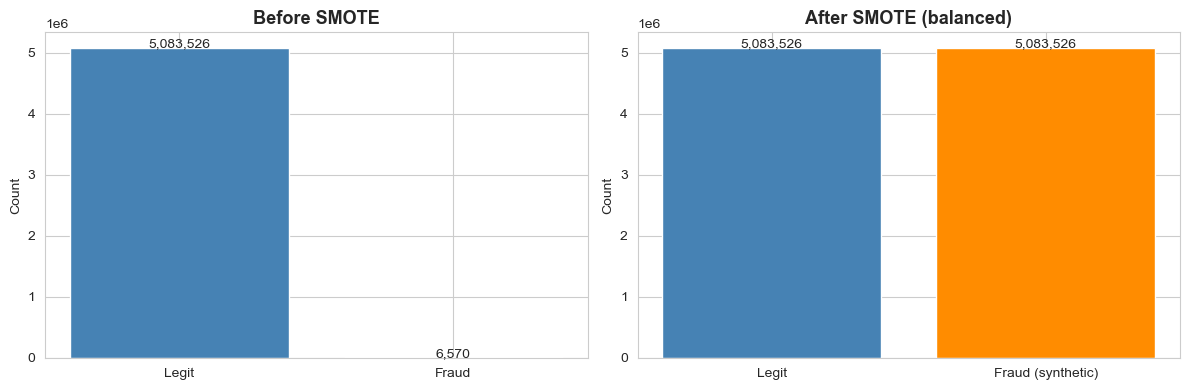

Note: SMOTE is applied inside the pipeline to prevent data leakage


In [8]:
# Show the imbalance visually
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
counts_before = y_train.value_counts()
axes[0].bar(['Legit', 'Fraud'], counts_before.values, color=['steelblue', 'crimson'])
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# After SMOTE (simulated for visualization)
smote_counts = [counts_before[0], counts_before[0]]  # SMOTE matches majority class
axes[1].bar(['Legit', 'Fraud (synthetic)'], smote_counts, color=['steelblue', 'darkorange'])
axes[1].set_title('After SMOTE (balanced)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(smote_counts):
    axes[1].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: SMOTE is applied inside the pipeline to prevent data leakage')

## 6. Build the XGBoost + SMOTE Pipeline

In [9]:
# Calculate scale_pos_weight — XGBoost's built-in imbalance handler
# This tells XGBoost how much more to penalise missing fraud vs missing legit
fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {fraud_ratio:.1f}x (fraud penalised {fraud_ratio:.0f}x more)')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=fraud_ratio,  # handles imbalance natively
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',           # area under precision-recall curve — right metric for imbalanced data
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# ImbPipeline from imbalanced-learn — applies SMOTE only during .fit(), not .predict()
pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', xgb_model)
])

print('Pipeline built ✅')
print('Steps:', [step[0] for step in pipeline.steps])

scale_pos_weight: 773.7x (fraud penalised 774x more)
Pipeline built ✅
Steps: ['prep', 'smote', 'clf']


In [10]:
print('Training XGBoost pipeline... (this may take a few minutes on 5M rows)')
pipeline.fit(X_train, y_train)
print('Training complete ✅')

Training XGBoost pipeline... (this may take a few minutes on 5M rows)
Training complete ✅


## 7. Evaluation — Using the Right Metrics

> ⚠️ **Accuracy is meaningless here.** A model that predicts "not fraud" 100% of the time gets 99.87% accuracy. We care about:
> - **Precision**: Of flagged transactions, how many are real fraud? (false alarm rate)
> - **Recall**: Of real fraud, how many did we catch? (miss rate)
> - **F1**: Harmonic mean of the two
> - **AUC-PR**: Area under precision-recall curve — the gold standard for imbalanced classification

In [11]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print('=' * 55)
print('CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

auc_roc = roc_auc_score(y_test, y_prob)
auc_pr  = average_precision_score(y_test, y_prob)
print(f'ROC-AUC:  {auc_roc:.4f}')
print(f'AUC-PR:   {auc_pr:.4f}  ← most important metric for fraud detection')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1270881
       Fraud       0.30      1.00      0.46      1643

    accuracy                           1.00   1272524
   macro avg       0.65      1.00      0.73   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC:  0.9992
AUC-PR:   0.9984  ← most important metric for fraud detection


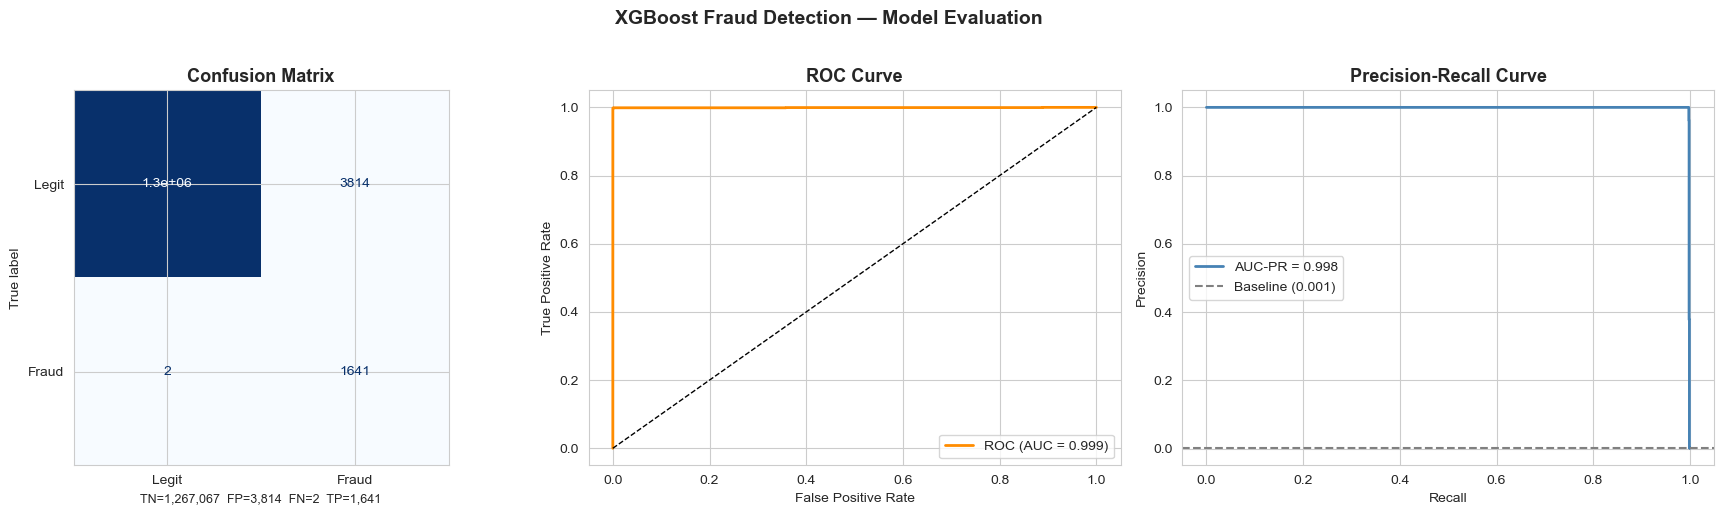

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}', fontsize=9)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()

# --- Precision-Recall Curve ---
prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, color='steelblue', lw=2, label=f'AUC-PR = {auc_pr:.3f}')
baseline = y_test.mean()
axes[2].axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[2].legend()

plt.suptitle('XGBoost Fraud Detection — Model Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Threshold Tuning
XGBoost outputs a probability (0–1). The default decision threshold is 0.5, but we can tune it to control the precision/recall tradeoff depending on business needs.

> **Business framing:** A bank might prefer higher recall (catch more fraud, accept some false alarms) vs. a payment processor that needs high precision (don't block innocent customers).

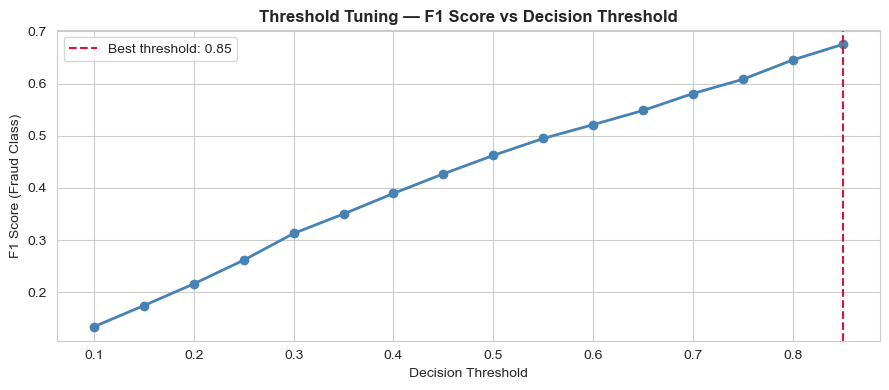


Default threshold (0.5): F1 = 0.462
Optimal threshold (0.85): F1 = 0.675


In [13]:
# Find the threshold that maximises F1 score
f1_scores = []
threshold_range = np.arange(0.1, 0.9, 0.05)

for thresh in threshold_range:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    from sklearn.metrics import f1_score
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

best_thresh = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(9, 4))
plt.plot(threshold_range, f1_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_thresh, color='crimson', linestyle='--', label=f'Best threshold: {best_thresh:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score (Fraud Class)')
plt.title('Threshold Tuning — F1 Score vs Decision Threshold', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDefault threshold (0.5): F1 = {f1_scores[list(threshold_range).index(min(threshold_range, key=lambda x: abs(x-0.5)))]:.3f}')
print(f'Optimal threshold ({best_thresh:.2f}): F1 = {best_f1:.3f}')

In [14]:
# Final report at optimal threshold
y_pred_optimal = (y_prob >= best_thresh).astype(int)
print(f'=== Final Report at Optimal Threshold ({best_thresh:.2f}) ===')
print(classification_report(y_test, y_pred_optimal, target_names=['Legit', 'Fraud']))

cm_opt = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm_opt.ravel()
print(f'True Positives  (fraud caught):      {tp:,}')
print(f'False Positives (innocent flagged):  {fp:,}')
print(f'False Negatives (fraud missed):      {fn:,}')
print(f'True Negatives  (legit approved):    {tn:,}')

=== Final Report at Optimal Threshold (0.85) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1270881
       Fraud       0.51      1.00      0.68      1643

    accuracy                           1.00   1272524
   macro avg       0.75      1.00      0.84   1272524
weighted avg       1.00      1.00      1.00   1272524

True Positives  (fraud caught):      1,640
False Positives (innocent flagged):  1,576
False Negatives (fraud missed):      3
True Negatives  (legit approved):    1,269,305


## 9. Feature Importance

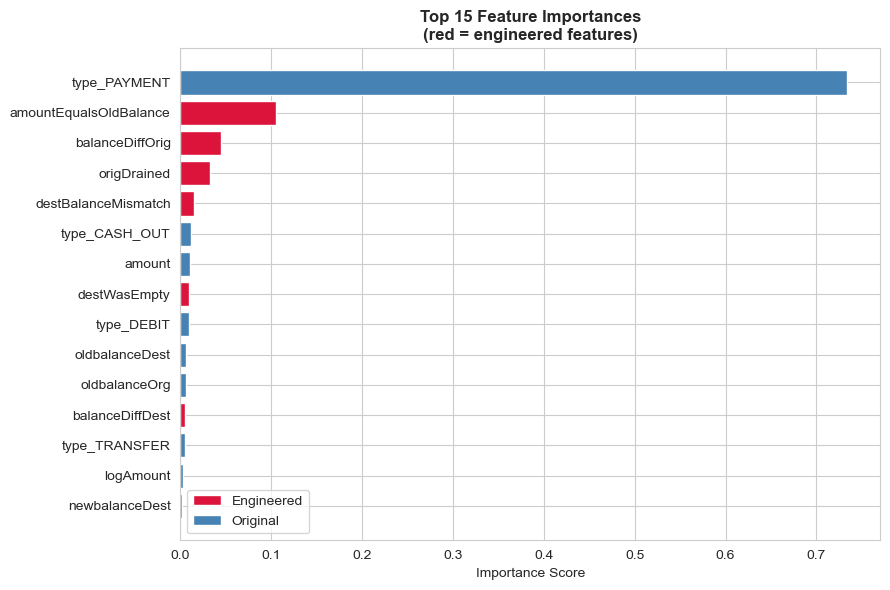

In [15]:
# Extract feature names after preprocessing
num_feature_names = numeric_features
cat_feature_names = pipeline.named_steps['prep']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features).tolist()
all_feature_names = num_feature_names + cat_feature_names

importances = pipeline.named_steps['clf'].feature_importances_
feat_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(9, 6))
colors = ['crimson' if f in ['origDrained', 'amountEqualsOldBalance', 'destWasEmpty',
                              'destBalanceMismatch', 'balanceDiffOrig', 'balanceDiffDest']
          else 'steelblue' for f in feat_df['feature']]
plt.barh(feat_df['feature'], feat_df['importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances\n(red = engineered features)', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='crimson', label='Engineered'),
                   Patch(facecolor='steelblue', label='Original')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Comparison — Old vs New

                   Logistic Regression (old)  XGBoost + SMOTE (new)
Metric                                                             
Precision (Fraud)                     0.0221                 0.5100
Recall (Fraud)                        0.9434                 0.9982
F1 (Fraud)                            0.0432                 0.6750
ROC-AUC                               0.9901                 0.9992
AUC-PR                                0.5605                 0.9984


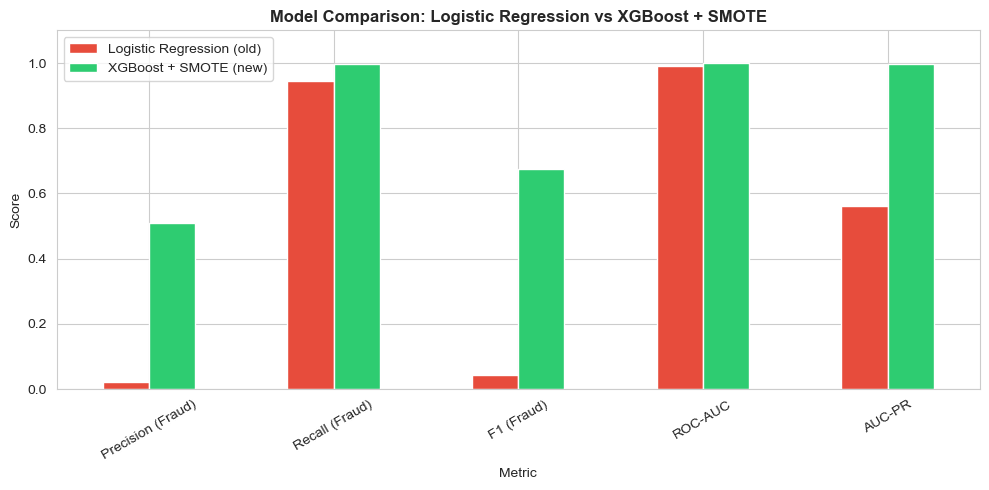

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline

# Recreate old pipeline for fair comparison
old_pipeline = SkPipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']),
        ('cat', OneHotEncoder(drop='first'), ['type'])
    ])),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

old_pipeline.fit(X_train, y_train)
old_prob = old_pipeline.predict_proba(X_test)[:, 1]
old_pred = old_pipeline.predict(X_test)

from sklearn.metrics import f1_score, precision_score, recall_score

comparison = pd.DataFrame({
    'Metric': ['Precision (Fraud)', 'Recall (Fraud)', 'F1 (Fraud)', 'ROC-AUC', 'AUC-PR'],
    'Logistic Regression (old)': [
        precision_score(y_test, old_pred),
        recall_score(y_test, old_pred),
        f1_score(y_test, old_pred),
        roc_auc_score(y_test, old_prob),
        average_precision_score(y_test, old_prob)
    ],
    'XGBoost + SMOTE (new)': [
        precision_score(y_test, y_pred_optimal),
        recall_score(y_test, y_pred_optimal),
        f1_score(y_test, y_pred_optimal),
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob)
    ]
})

comparison = comparison.set_index('Metric').round(4)
print(comparison.to_string())

# Visualise
comparison.plot(kind='bar', figsize=(10, 5), color=['#e74c3c', '#2ecc71'], edgecolor='white')
plt.title('Model Comparison: Logistic Regression vs XGBoost + SMOTE', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Export Production Pipeline

In [17]:
# Save the pipeline + optimal threshold together
model_artifact = {
    'pipeline': pipeline,
    'threshold': best_thresh,
    'feature_names': numeric_features + categorical_features,
    'metadata': {
        'model': 'XGBoost + SMOTE',
        'roc_auc': round(auc_roc, 4),
        'auc_pr': round(auc_pr, 4),
        'optimal_threshold': round(float(best_thresh), 2)
    }
}

joblib.dump(model_artifact, 'fraud_detection_v2.pkl')
print('Pipeline saved to fraud_detection_v2.pkl ✅')
print(f"Metadata: {model_artifact['metadata']}")

Pipeline saved to fraud_detection_v2.pkl ✅
Metadata: {'model': 'XGBoost + SMOTE', 'roc_auc': 0.9992, 'auc_pr': 0.9984, 'optimal_threshold': 0.85}


## 12. Streamlit App — Inference Helper
Paste this into `app.py` for your Streamlit deployment.

In [21]:
# streamlit_code = 
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load model artifact
artifact = joblib.load('fraud_detection_v2.pkl')
pipeline = artifact['pipeline']
threshold = artifact['threshold']

st.set_page_config(page_title='Fraud Detector', page_icon='🔍', layout='centered')
st.title('💳 Credit Card Fraud Detector')
st.markdown("""Powered by **XGBoost + SMOTE** trained on 6.3M transactions.  
Enter transaction details below to get a real-time fraud probability."""
)

with st.form('transaction_form'):
    col1, col2 = st.columns(2)
    with col1:
        txn_type    = st.selectbox('Transaction Type', ['TRANSFER', 'CASH_OUT', 'PAYMENT', 'DEBIT', 'CASH_IN'])
        amount      = st.number_input('Amount ($)', min_value=0.0, value=10000.0, step=100.0)
        old_bal_org = st.number_input('Sender Old Balance ($)', min_value=0.0, value=50000.0)
        new_bal_org = st.number_input('Sender New Balance ($)', min_value=0.0, value=40000.0)
    with col2:
        old_bal_dest = st.number_input('Receiver Old Balance ($)', min_value=0.0, value=0.0)
        new_bal_dest = st.number_input('Receiver New Balance ($)', min_value=0.0, value=10000.0)
    submitted = st.form_submit_button('🔍 Analyse Transaction')

if submitted:
    input_df = pd.DataFrame([{
        'type': txn_type,
        'amount': amount,
        'oldbalanceOrg': old_bal_org,
        'newbalanceOrig': new_bal_org,
        'oldbalanceDest': old_bal_dest,
        'newbalanceDest': new_bal_dest,
        'balanceDiffOrig': old_bal_org - new_bal_org,
        'balanceDiffDest': new_bal_dest - old_bal_dest,
        'origDrained': int(old_bal_org > 0 and new_bal_org == 0),
        'amountEqualsOldBalance': int(amount == old_bal_org),
        'destBalanceMismatch': abs((new_bal_dest - old_bal_dest) - amount),
        'logAmount': np.log1p(amount),
        'destWasEmpty': int(old_bal_dest == 0)
    }])

    prob = pipeline.predict_proba(input_df)[0][1]
    is_fraud = prob >= threshold

    st.divider()
    if is_fraud:
        st.error(f'⚠️ **FRAUD DETECTED** — Confidence: {prob*100:.1f}%')
    else:
        st.success(f'✅ **Legitimate Transaction** — Fraud probability: {prob*100:.1f}%')

    st.metric('Fraud Probability', f'{prob*100:.2f}%')
    st.progress(float(prob))


with open('app.py', 'w') as f:
    f.write(streamlit_code.strip())

print('app.py saved ✅ — run with: streamlit run app.py')

ModuleNotFoundError: No module named 'streamlit'